# Project 1

## 1. Objective
This project explores survey data to investigate (1) women's representation in Data Science and Machine Learning and (2) the relationship between educational attainment and income level. To address these questions, a range of statistical techniques, including hypothesis testing, regression analysis, and bootstrapping, are applied to extract meaningful insights from the data.

In [1]:
#@title Import the needed libraries
#@markdown Run this block to import the dependencies.

import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
%matplotlib inline
try:
    import pingouin as pg
except:
    !pip install pingouin
    import pingouin as pg

import os
import sys
from pathlib import Path

print(f"Python {sys.version.split()[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.1 MB/s eta 0:00:00
Python 3.12.13


In [2]:
#@title Load the project files
#@markdown Run this block to Load `Machine-learning-Portfolio`.
!git clone https://github.com/ali-sh-96/Machine-learning-Portfolio.git

# Get the path to the installed package.
root_dir = Path("Machine-learning-Portfolio")
# Select project
project_name = "project1"
project_dir = root_dir / project_name

Cloning into 'Machine-learning-Portfolio'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 88 (delta 25), reused 44 (delta 16), pack-reused 32 (from 1)
Receiving objects: 100% (88/88), 79.68 MiB | 9.03 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (26/26), done.


In [3]:
#@title Reading the data
#@markdown Run this block to read the CSV file.
df = pd.read_csv(project_dir / "clean_kaggle_data.csv", low_memory=False)
print(f"Dataset shape: {df.shape}")

Dataset shape: (15391, 370)


## 2. Exploratory Data Analysis

In this section, we perform exploratory data analysis (EDA) to summarize the main characteristics and patterns within the survey dataset. Three graphical visualizations are presented to highlight different trends and relationships in the data.

In [4]:
#@title Data exploration
#@markdown Assigning column names based on kaggle_survey_2021_answer_choices.pdf.
adf = df[['Q1', 'Q2', 'Q4', 'Q25']]
adf = adf.rename(columns={'Q1': 'age', 'Q2': 'gender', 'Q4': 'degree', 'Q25': 'salary'})
adf.head()

,age,gender,degree,salary
0,50-54,Man,Bachelor’s degree,30000
1,50-54,Man,Master’s degree,70000
2,22-24,Man,Master’s degree,1000
3,45-49,Man,Doctoral degree,40000
4,45-49,Man,Doctoral degree,40000


In [5]:
#@title Computing descriptive statistics
#@markdown Calculate the frequency of programming languages reported in Q7.

names = ['Q7_Part_' + str(i+1) for i in range(12)]
names += ['Q7_OTHER']

# Count occurrences of each programming language
lan = df[names].notna().sum().sort_values(ascending=False)

# Convert to DataFrame
lan = lan.reset_index()
lan.columns = ['Programming Language', 'Count']

lan

,Programming Language,Count
0,Q7_Part_1,12467
1,Q7_Part_3,7098
2,Q7_Part_2,3406
3,Q7_Part_7,2574
4,Q7_Part_5,2490
5,Q7_Part_6,2480
6,Q7_Part_4,2036
7,Q7_OTHER,1890
8,Q7_Part_10,1677
9,Q7_Part_11,1557


In [6]:
#@title Descriptive statistics for demographic variables
#@markdown Summarize the main demographic characteristics of survey respondents.

cat = adf[['age', 'gender', 'degree']]
cat.describe(include='all')

,age,gender,degree
count,15391,15391,15391
unique,11,5,7
top,25-29,Man,Master’s degree
freq,3235,12642,6799


In [7]:
#@title Computing salary descriptive statistics
#@markdown Summarize the distribution of respondent salaries.

salary = adf[['salary']]
salary.describe()

,salary
count,15391.000000
mean,49116.009356
std,98090.207788
min,1000.000000
25%,2000.000000
50%,15000.000000
75%,60000.000000
max,1000000.000000


### Education
Both pie chart and bar chart may be used to explore categorical data. Here, pie chart is used to visualize the “highest level of formal education:

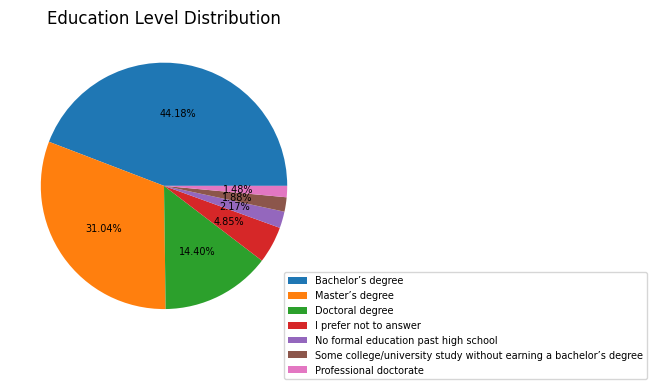

In [8]:
#@title Visualizing education level distribution
#@markdown Plot the proportion of respondents by highest education level.

degree = cat['degree'].unique()
n = len(degree)

# Hide labels on the pie chart and display them in the legend
labels = ['' for _ in range(n)]

cat['degree'].value_counts().plot(
    kind='pie',
    ylabel='',
    title='Education Level Distribution',
    autopct='%.2f%%',
    labels=labels,
    fontsize=7,
    figsize=(10, 4)
)

plt.legend(
    degree,
    fontsize=7,
    bbox_to_anchor=(1, 0),
    loc="lower right",
    bbox_transform=plt.gcf().transFigure
)

plt.show()

### Age groups
Age groupes may be treated as either categorical data or binned quantitative data. For the current data, the bin ranges are as follows:<br>
\begin{align}
[18, 22) && [22, 25) &&[25, 30) &&[30, 35) && [35, 40) &&[40, 45)\\
[45, 50) &&[50, 55) && [55, 60) &&[60, 70) && [70, \infty)
\end{align}

Rearranging the bins:

In [9]:
#@title Computing age group statistics
#@markdown Reorganize age categories and calculate the number of respondents in each group.

# Count respondents in each age group
age_counts = cat['age'].value_counts()

# Extract age group labels
age_groups = age_counts.index.tolist()

# Convert age ranges into numerical bins
bins = age_counts.index.str.replace('+', '-100').str.split('-').tolist()
bins = [[int(j) for j in i] for i in bins]

# Combine age ranges, labels, and counts
age_summary = pd.DataFrame(
    list(zip(bins, age_groups, age_counts.tolist())),
    columns=['Age Range', 'Age Group', 'Count']
)

age_summary

,Age Range,Age Group,Count
0,"[25, 29]",25-29,3235
1,"[30, 34]",30-34,2626
2,"[22, 24]",22-24,2092
3,"[35, 39]",35-39,1992
4,"[40, 44]",40-44,1528
5,"[45, 49]",45-49,1141
6,"[18, 21]",18-21,931
7,"[50, 54]",50-54,791
8,"[55, 59]",55-59,504
9,"[60, 69]",60-69,454


The distribution of the age groups is visualized using both bar chart and histogram plot.

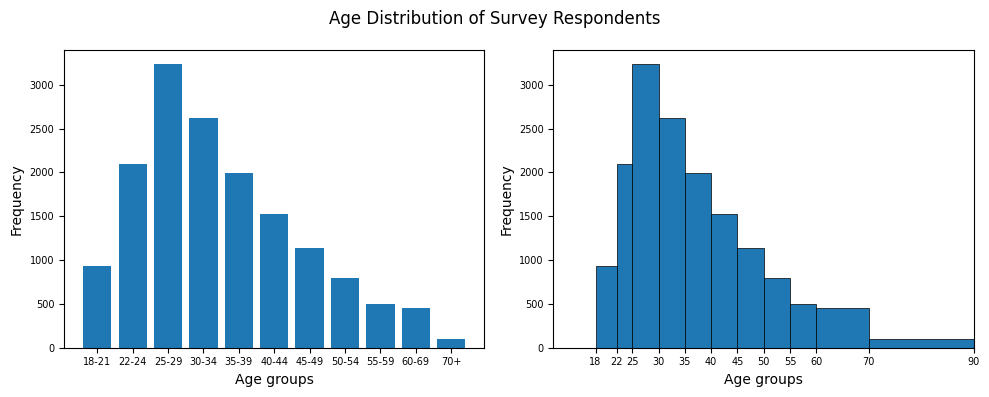

In [10]:
#@title Visualizing age distribution
#@markdown Plot the frequency of respondents across different age groups.

age_counts = adf['age'].value_counts()
age_groups = age_counts.index.tolist()
age_frequency = age_counts.values.tolist()

age_bins = age_counts.index.str.split('+').tolist()
age_bins = [item for sublist in age_bins for item in sublist]
age_bins = list(filter(None, age_bins))
age_bins = [i.split('-') for i in age_bins]
age_bins = [[int(j) for j in i] for i in age_bins]

hist_bins = [min(i) for i in age_bins]
sorted_data = sorted(zip(hist_bins, age_frequency, age_groups))
hist_bins, age_frequency, age_groups = map(list, zip(*sorted_data))

# Plot
upper_age = 90

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot of age groups
ax[0].bar(age_groups, age_frequency)

# Histogram representation
ax[1].hist(
    hist_bins,
    bins=hist_bins + [upper_age],
    weights=age_frequency,
    edgecolor='black',
    linewidth=0.5
)

ax[1].set_xlim(xmin=10, xmax=upper_age)
ax[1].set_xticks(hist_bins + [upper_age])

for axis in ax:
    axis.tick_params(axis='both', labelsize=7)
    axis.set_xlabel('Age groups')
    axis.set_ylabel('Frequency')

fig.suptitle('Age Distribution of Survey Respondents')
plt.tight_layout()
plt.show()

### Programming languages

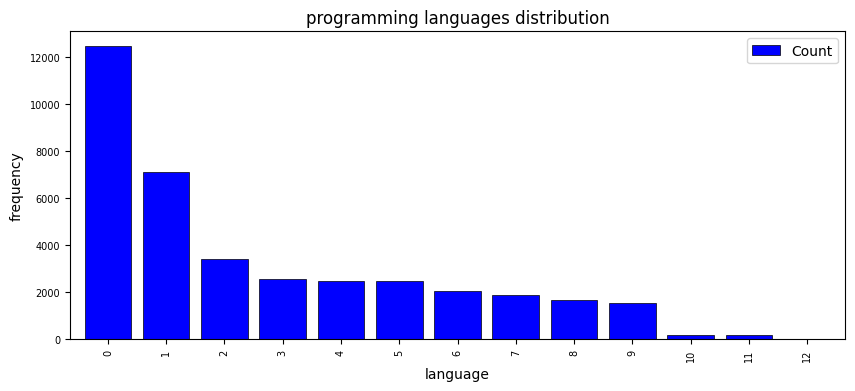

In [11]:
#@title Visualizing programming language distribution
#@markdown Plot the frequency of programming languages reported by respondents.

lan.plot.bar(width=0.8, xlabel='language', ylabel='frequency', title='programming languages distribution',
             color='blue', edgecolor='black', linewidth=0.5, fontsize=7, figsize=(10,4))
plt.show()

### Yearly compensation

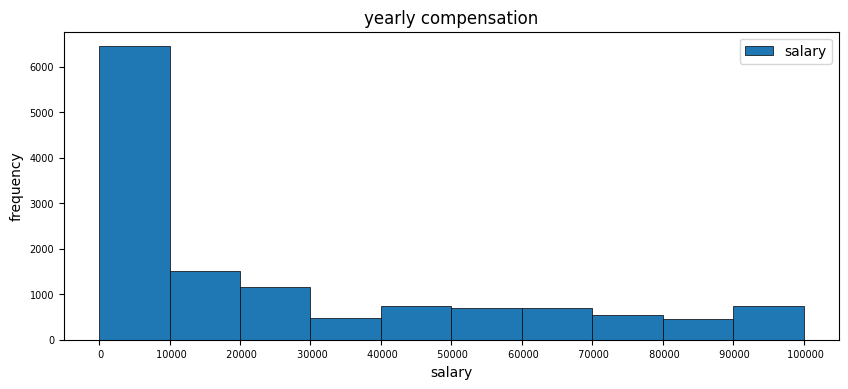

In [12]:
#@title Visualizing salary distribution
#@markdown Plot the distribution of yearly compensation among respondents.

bins = np.linspace(0, 100000, num=11)
salary.plot.hist(bins=bins, figsize = (10,4), title='yearly compensation',
                 edgecolor='black', linewidth=0.5, fontsize=7)
ax = plt.gca()
ax.set_xticks(bins)
ax.xaxis.set_major_formatter("{x: .0f}")
ax.set_xlabel('salary')
ax.set_ylabel('frequency')
plt.show()

## 3. Comparing Salary Differences Across Gender Groups
This section investigates whether there is a statistically significant difference in average salary between male and female respondents. The analysis focuses on the relationship between gender (Q2) and annual compensation (Q25).

1. Compute and report descriptive statistics for each group after removing missing data, if necessary.

2. Perform a two-sample t-test at a significance threshold of 0.05, if appropriate, and explain the rationale for applying this test.

3. Apply bootstrap resampling to compare the mean salary (Q25) between the two groups. The number of samples drawn from each group should be proportional to its original sample size. Use 1000 bootstrap replications. Plot the bootstrap distributions for the two groups (men and women), as well as the distribution of the difference in mean salaries.

4. Perform a two-sample t-test at a significance threshold of 0.05 on the bootstrap samples, if appropriate, and explain the rationale for this analysis.

5. Discuss and interpret the findings.

In [13]:
#@title Computing descriptive statistics for female respondents
#@markdown Extract female salary data and summarize its distribution.

female_salary = adf[adf['gender'] == 'Woman']['salary'].dropna()
Nx = female_salary.count()
female_salary.describe()

,salary
count,2482.000000
mean,34816.881547
std,72017.347888
min,1000.000000
25%,1000.000000
50%,7500.000000
75%,50000.000000
max,1000000.000000


In [14]:
#@title Computing descriptive statistics for male respondents
#@markdown Extract male salary data and summarize its distribution.

male_salary = adf[adf['gender'] == 'Man']['salary'].dropna()
Ny = male_salary.count()
male_salary.describe()

,salary
count,12642.000000
mean,51193.600696
std,99979.274378
min,1000.000000
25%,2000.000000
50%,20000.000000
75%,60000.000000
max,1000000.000000


### Hypothesis testing (independent samples t-test)

The assumptions for independent t-test are as follows:
1. Data values must be independent.
2. Data in each group are normally distributed.
3. The variances for the two independent groups are equal.

We have seen above that the mean `salary` for the male and female populations was different. Based on the central limit theorem, the distribution of the means approximates the normal distribution for large enough samples sizes.

Homogeneity of variance (HOV) may not be satisfied, especially since the male sample size is 5 times larger than the female sample size. The HOV assumption is evaluated using Levene's test with `scipy.stats.levene()`:

In [15]:
#@title Levene's test for equality of variances
#@markdown Test whether male and female salary groups have similar variances.

lev, p_value = st.levene(female_salary, male_salary)

print("Levene's test: statistic = %.4f, p-value = %.13f" % (lev, p_value))

Levene's test: statistic = 47.0172, p-value = 0.0000000000073


Hence, the difference in the variances is statistically significant (`p-value = 7.3e-12 < 0.05`). Welch’s t-test does not require the HOV condition and is used here instead of Student’s t-test:

In [16]:
#@title Welch's two-sample t-test
#@markdown Test whether the mean salaries of male and female respondents are significantly different.

tc, pc = st.ttest_ind(female_salary, male_salary, equal_var = False)
print ("t-test: t = %g  p = %g" % (tc, pc))

t-test: t = -9.64952  p = 7.95292e-22


In the case of the mean salary, it is concluded that men tend to have a higher income (`p-value = 8e-22 < 0.05`, statistically significant).

### Bootstrapping
Here, the number of instances used to sample each group is equal to its size. 1000 replications were used to obtain the bootstrapped distributions and the distribution of the difference in means.

In [17]:
#@title Bootstrap resampling for salary comparison
#@markdown Generate bootstrap distributions of mean salaries and their difference.

x = []
y = []
dif = []
N_resample = 1000
for _ in range(N_resample):
    x_sample = np.random.choice(female_salary, size=Nx, replace=True)
    x.append(x_sample.mean())
    y_sample = np.random.choice(male_salary, size=Ny, replace=True)
    y.append(y_sample.mean())
    dif.append(y_sample.mean()-x_sample.mean())

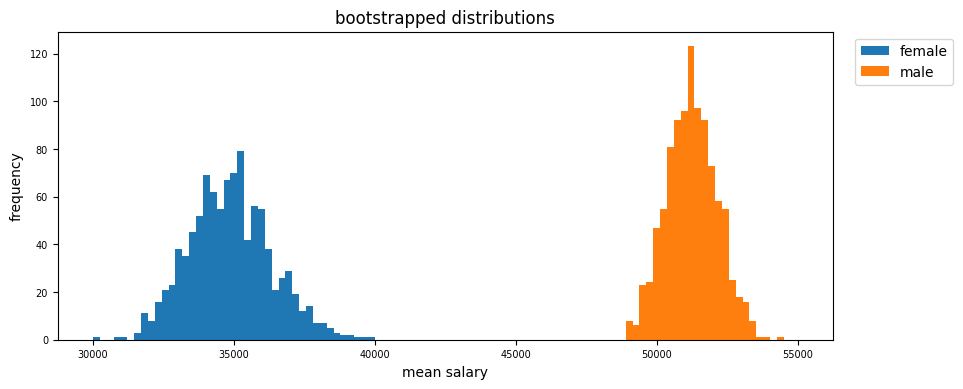

In [18]:
#@title Visualizing bootstrap distributions of mean salary
#@markdown Plot the bootstrap distributions of the estimated mean salaries.

plt.figure(figsize=(10,4))
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.hist(x, bins=41, range=[30000, 40000])
plt.hist(y, bins=41, range=[45000, 55000])
plt.title('bootstrapped distributions')
plt.xlabel('mean salary')
plt.ylabel('frequency')
plt.legend(['female', 'male'], bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

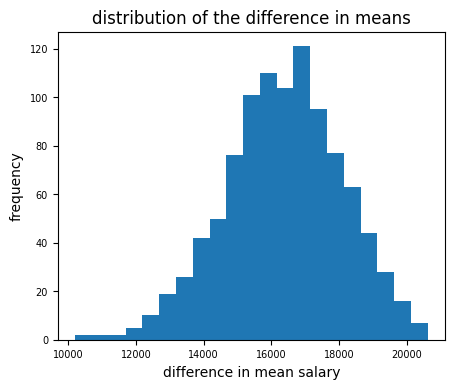

In [19]:
#@title Visualizing bootstrap distribution of mean salary difference
#@markdown Plot the distribution of differences between bootstrap mean salaries.

plt.figure(figsize=(5,4))
plt.title('distribution of the difference in means')
plt.xlabel('difference in mean salary')
plt.ylabel('frequency')
plt.hist(dif, bins=21)
plt.show()

In [20]:
#@title Computing bootstrap confidence interval
#@markdown Estimate the 95% confidence interval for the difference in mean salary.

conf_int = np.percentile(np.sort(dif), [2.5, 97.5])
print("The 95 % confidence interval is: ", conf_int)

The 95 % confidence interval is:  [12776.17319865 19536.51847566]


The confidence interval analysis shows that the difference in mean is significant.

To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is used. Note that Bartlett and F-test may also be used since the distribution of the means is normal according to the central limit theorem.

In [21]:
#@title Levene's test on bootstrap distributions
#@markdown Test whether bootstrap mean salary distributions have equal variances.

lev, pl = st.levene(x, y)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 186.631  p = 1.09564e-40


It is concluded that the difference in the variances is statistically significant (`p-value = 2.5e-41 < 0.05`). Therefore, Student's t-test may not be reliable and Welch's t-test should be used to compare the means of the two groups.

In [22]:
#@title Welch's t-test on bootstrap distributions
#@markdown Compare bootstrap mean salary distributions between male and female respondents.

tc, pc = st.ttest_ind(x, y, equal_var = False)
print ("t-test: t = %g  p = %g" % (tc, pc))

t-test: t = -297.949  p = 0


Again, it is concluded that men tend to have a higher income (`p-value = 0 < 0.05`, statistically significant).

## 4. Evaluating the Relationship Between Education Level and Salary

Select "highest level of formal education" (Q4) from the dataset and repeat the analysis steps performed in Question (2). In this analysis, compare the mean salary among three education groups: Bachelor's degree, Master's degree, and Doctoral degree.

Since more than two groups are being compared, analysis of variance (ANOVA) is used instead of a two-sample t-test for hypothesis testing.

#### Computing descriptive statistics:
Computing means of `salary` for the three groups:

In [23]:
#@title Computing mean salary by education level
#@markdown Calculate the average salary for each education group.

data = adf[['degree', 'salary']]
degree_data = data.groupby('degree')
degree_salary_mean = degree_data.mean()
degree_salary_mean

,salary
degree,
Bachelor’s degree,35578.291815
Doctoral degree,70641.181777
I prefer not to answer,34191.616766
Master’s degree,52706.868657
No formal education past high school,38208.333333
Professional doctorate,67465.517241
Some college/university study without earning a bachelor’s degree,41990.616622


Calculating descriptive statistics for `salary` of female population:

In [24]:
BS_salary = adf[adf['degree'] == 'Bachelor’s degree']['salary'].dropna()
Nx = BS_salary.count()
BS_salary.describe()

,salary
count,4777.000000
mean,35578.291815
std,89382.060777
min,1000.000000
25%,1000.000000
50%,7500.000000
75%,40000.000000
max,1000000.000000


In [25]:
MS_salary = adf[adf['degree'] == 'Master’s degree']['salary'].dropna()
Ny = MS_salary.count()
MS_salary.describe()

,salary
count,6799.000000
mean,52706.868657
std,90928.786678
min,1000.000000
25%,3000.000000
50%,25000.000000
75%,70000.000000
max,1000000.000000


In [26]:
PHD_salary = adf[adf['degree'] == 'Doctoral degree']['salary'].dropna()
Nz = PHD_salary.count()
PHD_salary.describe()

,salary
count,2217.000000
mean,70641.181777
std,117160.947589
min,1000.000000
25%,4000.000000
50%,40000.000000
75%,90000.000000
max,1000000.000000


### Hypothesis testing (one-way ANOVA)

The assumptions for one-way ANOVA are as follows:
1. Data values must be independent.
2. Data in each group are normally distributed.
3. The variances for the two independent groups are equal.

We have seen above that the mean `salary` for the three groups was different. Parametric tests of the mean are robust to departures from the normality according to the central limit theorem. In ANOVA, when homogeneity of variance is violated, there is a greater probability of falsely rejecting the null hypothesis. To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is performed:

In [27]:
#@title Levene's test for equality of variances
#@markdown Test whether salary variances are similar across education groups.

lev, pl = st.levene(BS_salary, MS_salary, PHD_salary)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 79.5475  p = 4.47424e-35


Since difference in the variances is statistically significant (`p-value = 4.47-35 < 0.05`). Therefore, ANOVA may not be reliable, and consequently, Welch's ANOVA with `pingouin.welch_anova()` is used to compare the means of the three groups:

In [28]:
#@title Performing Welch's ANOVA
#@markdown Test whether mean salary differs across education groups.

pg.welch_anova(dv='salary', between='degree', data=adf)

,Source,ddof1,ddof2,F,p_unc,np2
0,degree,6,1295.978657,34.623387,5.932756e-39,0.015042


Hence, we can reject the null hypothesis that the yearly salary is equal between the three groups (`p-value = 5.9e-39 < 0.05`).

### Bootstrapping
Here, the number of instances used to sample each group is equal to its size. 1000 replications were used to obtain the bootstrapped distributions and the distribution of the difference in means.

In [29]:
#@title Bootstrap resampling for education-based salary comparison
#@markdown Generate bootstrap distributions of mean salaries and pairwise differences.

x = []
y = []
z = []
dif_xy = []
dif_yz = []
dif_xz = []
N_resample = 1000
for _ in range(N_resample):
    x_sample = np.random.choice(BS_salary, size=Nx, replace=True)
    x.append(x_sample.mean())
    y_sample = np.random.choice(MS_salary, size=Ny, replace=True)
    y.append(y_sample.mean())
    z_sample = np.random.choice(PHD_salary, size=Nz, replace=True)
    z.append(z_sample.mean())
    dif_xy.append(y_sample.mean()-x_sample.mean())
    dif_yz.append(z_sample.mean()-y_sample.mean())
    dif_xz.append(z_sample.mean()-x_sample.mean())

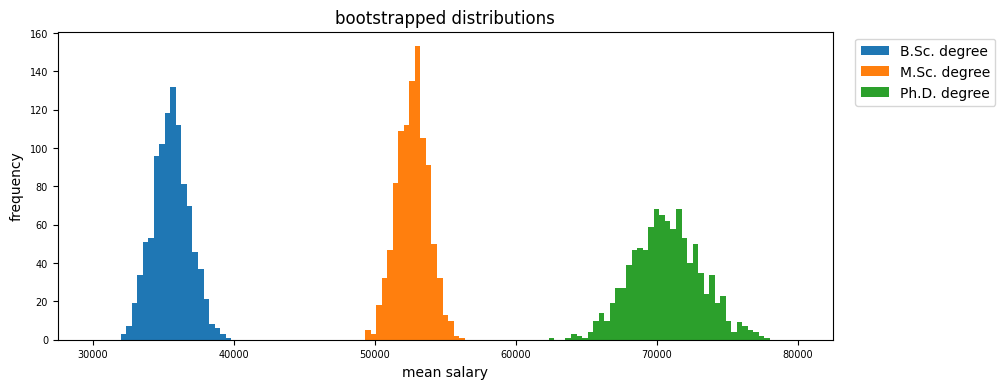

In [30]:
#@title Visualizing bootstrap distributions of mean salary
#@markdown Plot bootstrap distributions for each education group.

plt.figure(figsize=(10,4))
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.hist(x, bins=51, range=[30000, 50000])
plt.hist(y, bins=51, range=[45000, 65000])
plt.hist(z, bins=51, range=[60000, 80000])
plt.title('bootstrapped distributions')
plt.xlabel('mean salary')
plt.ylabel('frequency')
plt.legend(['B.Sc. degree', 'M.Sc. degree', 'Ph.D. degree'], bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

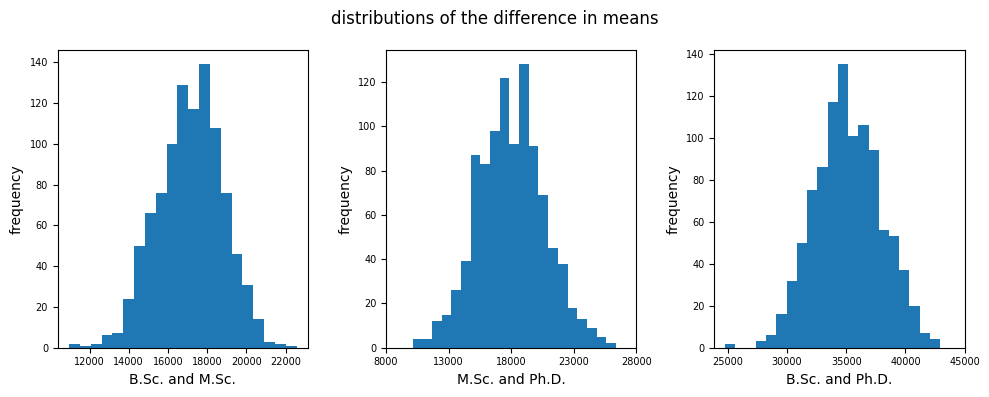

In [31]:
#@title Visualizing bootstrap distributions of salary differences
#@markdown Plot pairwise bootstrap distributions of mean salary differences.

fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].hist(dif_xy, bins=21)
ax[1].hist(dif_yz, bins=21)
ax[2].hist(dif_xz, bins=21)
ax[0].set_xticks([12000+2000*i for i in range(6)])
ax[1].set_xticks([8000+5000*i for i in range(5)])
ax[2].set_xticks([25000+5000*i for i in range(5)])
ax[0].set_xlabel('B.Sc. and M.Sc.')
ax[1].set_xlabel('M.Sc. and Ph.D.')
ax[2].set_xlabel('B.Sc. and Ph.D.')
for i in range(3):
    ax[i].tick_params(axis='both', labelsize=7)
    ax[i].set_ylabel('frequency')
fig.suptitle('distributions of the difference in means')
plt.tight_layout()
plt.show()

To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is performed:

In [32]:
#@title Levene's test on bootstrap distributions
#@markdown Test whether bootstrap mean salary distributions have equal variances across education groups.

lev, pl = st.levene(x, y, z)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 313.993  p = 1.56492e-124


Levene's test indicates that the difference in the variances is statistically significant (`p-value = 1.4e-136 < 0.05`). Therefore, ANOVA may not be reliable and Welch's ANOVA should be used to compare the means of the three bootstrapped data:

In [33]:
#@title Creating bootstrap dataset for ANOVA
#@markdown Combine bootstrap mean salary estimates into a structured DataFrame.

bdf = pd.DataFrame({'degree': np.repeat(['Bachelor’s degree', 'Master’s degree', 'Doctoral degree'],
                                      repeats=1000), 'salary': x+y+z})
bdf.head()

,degree,salary
0,Bachelor’s degree,34388.319029
1,Bachelor’s degree,33411.660038
2,Bachelor’s degree,36759.472472
3,Bachelor’s degree,38833.054218
4,Bachelor’s degree,36602.679506


In [34]:
#@title Performing Welch's ANOVA on bootstrap samples
#@markdown Test whether bootstrap mean salaries differ across education groups.

pg.welch_anova(dv='salary', between='degree', data=bdf)

,Source,ddof1,ddof2,F,p_unc,np2
0,degree,2,1875.672982,97851.722919,0.0,0.98574


Hence, we can reject the null hypothesis that the yearly salary is equal between the three groups (`p-value = 0.0 < 0.05`).